# HanSeg to NPZ Conversion and Visualization

This notebook converts HanSeg dataset `.nrrd` files into a unified `.npz` format for testing.

In [1]:
import sys
from pathlib import Path

parent = Path().resolve().parent.parent 
sys.path.append(str(parent))

In [2]:
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices, plot_one_dp
import numpy as np

from data.test_data.han_seg_to_npz import CTProcessor, MRIProcessor

# CT

In [6]:
proc = CTProcessor("HanSeg/set_1", oar_csv_path="HanSeg/set_1/OAR_data.csv")
proc.process_dataset("han_seg_ct")

Loading OAR availability from HanSeg/set_1/OAR_data.csv

[1/4] Processing case_04 ...
  Resampling from spacing ('2.00', '0.60', '0.60') mm → 1.0 mm isotropic ...
  -> Resampled shape: (278, 400, 565)
  -> Success: shape (278, 400, 565), modality=CT

[2/4] Processing case_18 ...
  Resampling from spacing ('3.00', '0.61', '0.61') mm → 1.0 mm isotropic ...
  -> Resampled shape: (363, 440, 567)
  -> Success: shape (363, 440, 567), modality=CT

[3/4] Processing case_25 ...
  Resampling from spacing ('2.00', '0.68', '0.68') mm → 1.0 mm isotropic ...
  -> Resampled shape: (294, 425, 573)
  -> Success: shape (294, 425, 573), modality=CT

[4/4] Processing case_40 ...
  Resampling from spacing ('2.00', '0.59', '0.59') mm → 1.0 mm isotropic ...
  -> Resampled shape: (310, 403, 563)
  -> Success: shape (310, 403, 563), modality=CT

Saving dataset to han_seg_ct.npz ...
Save complete!

OAR Mapping: {'A_Carotid_L': 1, 'A_Carotid_R': 2, 'Arytenoid': 3, 'Bone_Mandible': 4, 'Brainstem': 5, 'BuccalMucos

In [3]:
dg_ct = DataGenerator(DataLoader_npz(["data/test_data/han_seg_ct.npz"], val_size=0.0))


Loading NPZ dataset(s)…
Loaded 4 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\han_seg_ct.npz

Final dataset size: 4 patients.



In [4]:
print(dg_ct.dataloader.train_ids)
print(dg_ct.dataloader.validation_ids)

['han_seg_ct_case_40', 'han_seg_ct_case_25', 'han_seg_ct_case_18', 'han_seg_ct_case_04']
[]


In [5]:
img_ct = dg_ct.dataloader.dataset['han_seg_ct_case_04']['image']
segmentations_ct = dg_ct.dataloader.dataset['han_seg_ct_case_04']['segmentations']

In [6]:
print(segmentations_ct[0].shape)
print(img_ct.shape)

(278, 400, 565)
(278, 400, 565)


In [7]:
visualize_img_with_mask(img_ct, segmentations_ct[0])

interactive(children=(IntSlider(value=139, description='Slice:', max=277), Output()), _dom_classes=('widget-in…

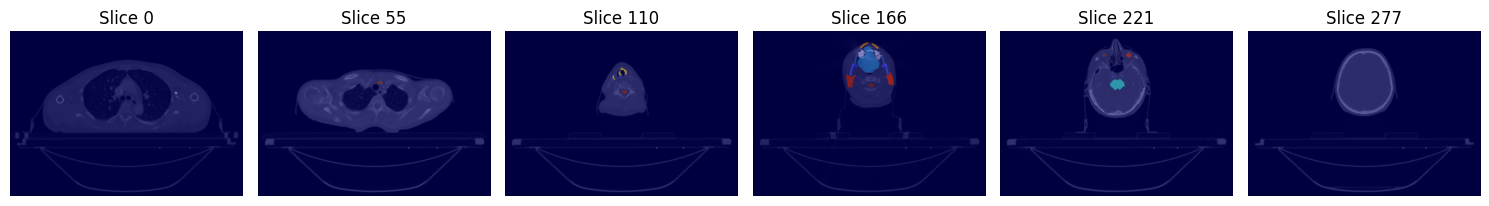

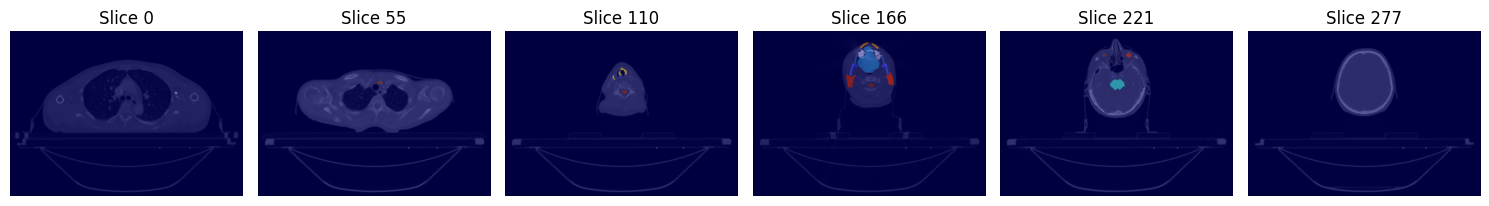

In [8]:
plot_vol_slices(img_ct, segmentations_ct[0], num_slices=6)

In [9]:
x_np, y_np, p_np, m_np, offset_list = dg_ct.get_data_points_numpy(max_data_points=100, offset=10, max_number_labels=3)

Creating new Data Points ...
It took 4 seconds


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


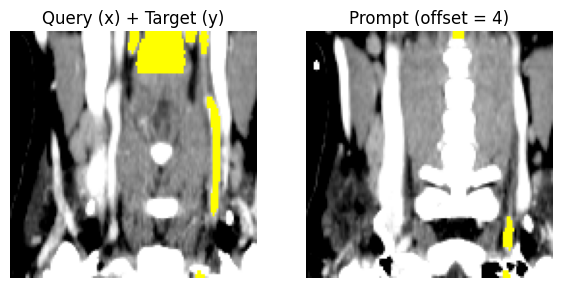

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


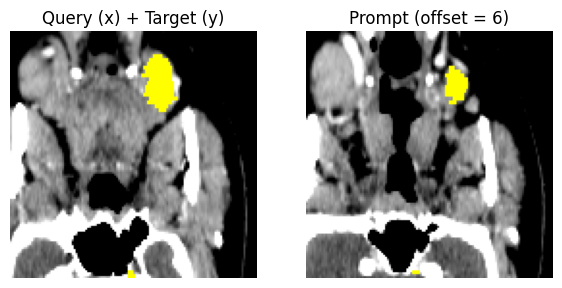

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


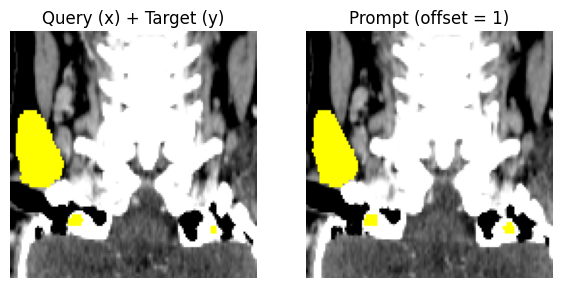

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


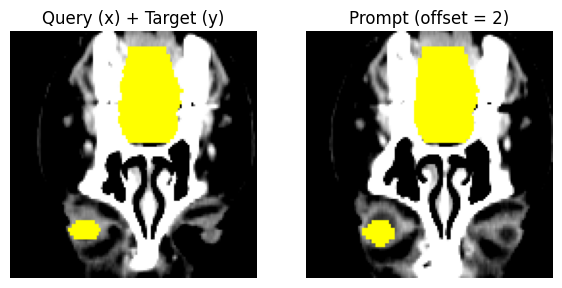

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


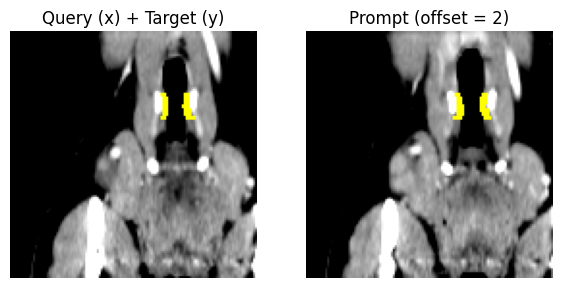

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


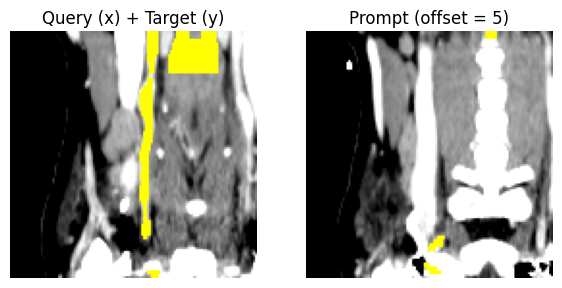


x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


In [10]:
for dp_idx in range(x_np.shape[0]):
    x, y, p = x_np[dp_idx,...], y_np[dp_idx,...], p_np[dp_idx,...]
    plot_one_dp(x,y,p, offset_list[dp_idx])
    print(f'x: {np.min(x)} - {np.max(x)} | y: {np.min(y)} - {np.max(y)} | p (img): {np.min(p[...,0])} - {np.max(p[...,0])} | p (roi): {np.min(p[...,1])} - {np.max(p[...,1])}')
    print(np.unique(y), np.unique(p[...,1]))
    print(x.dtype, y.dtype, p[...,0].dtype, p[...,1].dtype)
    if dp_idx == 5:
        break

# MRI

In [ ]:
proc = MRIProcessor("HanSeg/set_1", oar_csv_path="HanSeg/set_1/OAR_data.csv")
proc.process_dataset("han_seg_mri")

Loading OAR availability from HanSeg/set_1/OAR_data.csv

[1/4] Processing case_04 ...
  Registration OK  (metric = -0.5166)
  Resampling from spacing ('2.00', '0.60', '0.60') mm → 1.0 mm isotropic ...
  -> Resampled shape: (174, 259, 254)
  -> Success: shape (174, 259, 254), modality=MRI

[2/4] Processing case_18 ...
  Registration OK  (metric = -0.5869)
  Resampling from spacing ('3.00', '0.61', '0.61') mm → 1.0 mm isotropic ...
  -> Resampled shape: (213, 270, 266)
  -> Success: shape (213, 270, 266), modality=MRI

[3/4] Processing case_25 ...
  Registration OK  (metric = -0.7025)
  Resampling from spacing ('2.00', '0.68', '0.68') mm → 1.0 mm isotropic ...
  -> Resampled shape: (232, 262, 258)
  -> Success: shape (232, 262, 258), modality=MRI

[4/4] Processing case_40 ...
  Registration OK  (metric = -0.6519)
  Resampling from spacing ('2.00', '0.59', '0.59') mm → 1.0 mm isotropic ...
  -> Resampled shape: (210, 261, 258)
  -> Success: shape (210, 261, 258), modality=MRI

Saving data

In [11]:
dg_mr = DataGenerator(DataLoader_npz(["data/test_data/han_seg_mri.npz"], val_size=0.0))


Loading NPZ dataset(s)…
Loaded 4 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\han_seg_mri.npz

Final dataset size: 4 patients.



In [12]:
img_mr = dg_mr.dataloader.dataset['han_seg_mri_case_04']['image']
segmentations_mr = dg_mr.dataloader.dataset['han_seg_mri_case_04']['segmentations']

In [13]:
print(segmentations_mr[0].shape)
print(img_mr.shape)

(174, 259, 254)
(174, 259, 254)


In [14]:
visualize_img_with_mask(img_mr, segmentations_mr[0])

interactive(children=(IntSlider(value=87, description='Slice:', max=173), Output()), _dom_classes=('widget-int…

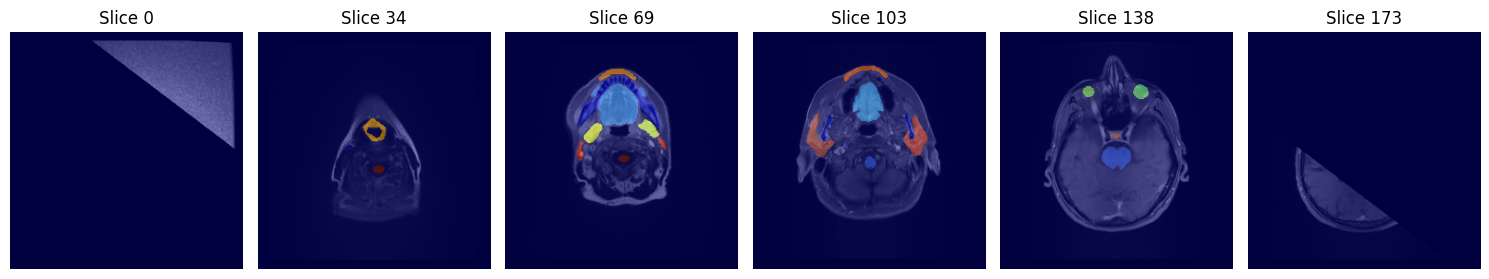

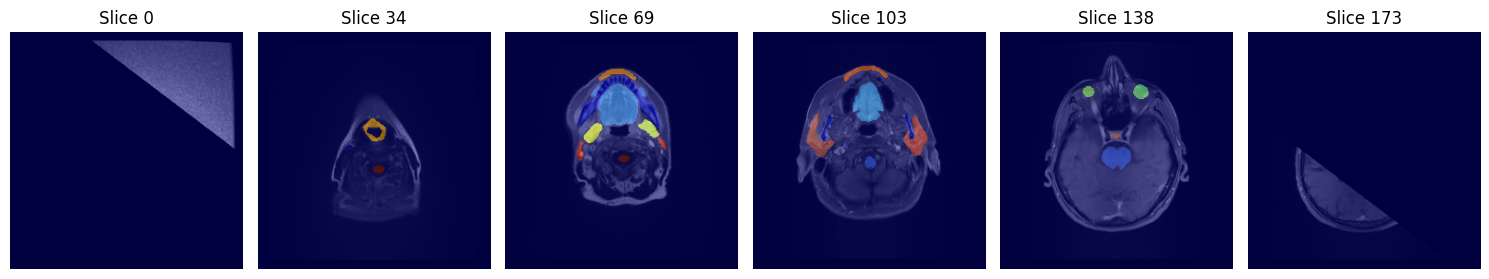

In [15]:
plot_vol_slices(img_mr, segmentations_mr[0], num_slices=6)

In [18]:
ds, offset_list = dg_mr.get_data_points(max_data_points=10, offset=10, max_number_labels=3)

Creating new Data Points ...
It took 1 seconds


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67796457..3.80104].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6894257..3.80104].


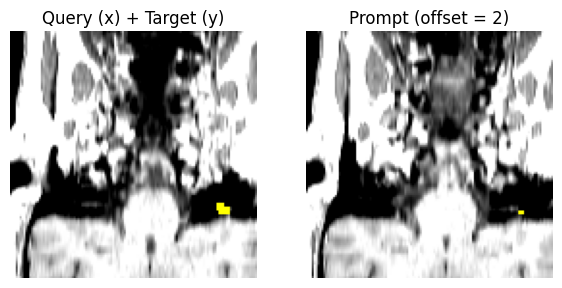

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6894257..3.80104].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6871335..3.80104].



x: -0.6779645681381226 - 3.801039934158325 | y: 0.0 - 1.0 | p (img): -0.6894257068634033 - 3.801039934158325 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


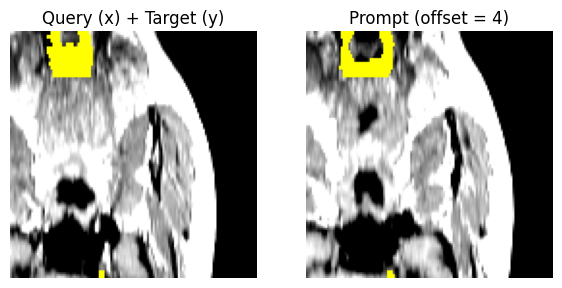

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6802568..3.80104].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67338014..3.80104].



x: -0.6894257068634033 - 3.801039934158325 | y: 0.0 - 1.0 | p (img): -0.6871334910392761 - 3.801039934158325 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


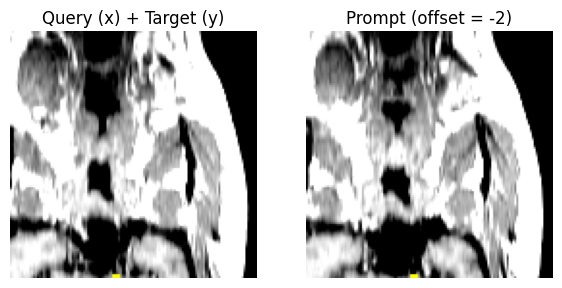

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.80104].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.80104].



x: -0.6802567839622498 - 3.801039934158325 | y: 0.0 - 1.0 | p (img): -0.6733801364898682 - 3.801039934158325 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


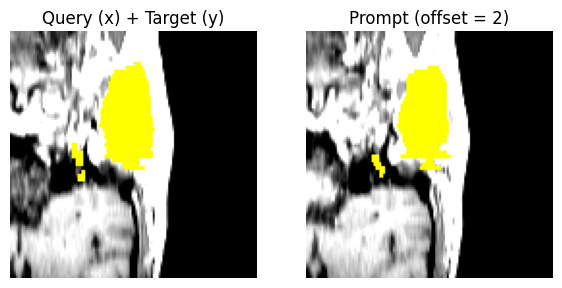

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.620659..3.80104].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6389968..3.80104].



x: -5.0 - 3.801039934158325 | y: 0.0 - 1.0 | p (img): -5.0 - 3.801039934158325 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


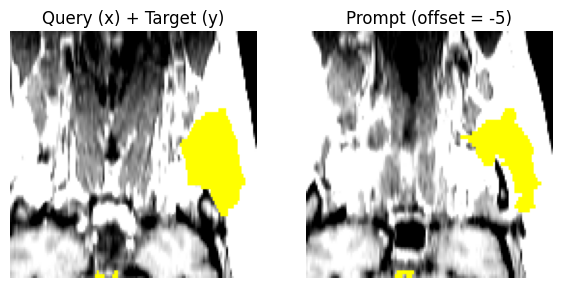

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.70317906..3.80104].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7077635..3.80104].



x: -0.6206589937210083 - 3.801039934158325 | y: 0.0 - 1.0 | p (img): -0.6389967799186707 - 3.801039934158325 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


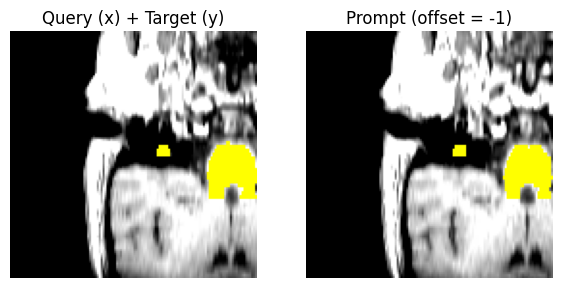


x: -0.7031790614128113 - 3.801039934158325 | y: 0.0 - 1.0 | p (img): -0.7077634930610657 - 3.801039934158325 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


In [19]:
for counter,(x,y,p,m) in enumerate(ds):
    plot_one_dp(x,y,p, offset_list[counter])
    print(f'x: {np.min(x)} - {np.max(x)} | y: {np.min(y)} - {np.max(y)} | p (img): {np.min(p[...,0])} - {np.max(p[...,0])} | p (roi): {np.min(p[...,1])} - {np.max(p[...,1])}')
    print(np.unique(y), np.unique(p[...,1]))
    print(x.dtype, y.dtype, p[...,0].dtype, p[...,1].dtype)
    if counter == 5:
        break